# HairNet Compliance Detection

### Deployment — REST API Test

This notebook:
1. Checks if the FastAPI app is already running
2. Starts it automatically if not
3. Sends test images from the test set to `/predict`
4. Displays the annotated images and JSON response

##  Install Dependencies

In [ ]:
!pip install requests pillow -q

## 1. Start API Server (if not running)

In [1]:
import requests
import subprocess
import time
import sys
from pathlib import Path

API_URL  = 'http://localhost:8000'
APP_FILE = Path('app.py')

def is_api_running():
    try:
        r = requests.get(f'{API_URL}/health', timeout=3)
        return r.status_code == 200
    except Exception:
        return False

if is_api_running():
    print('API already running ✓')
else:
    print('Starting API server...')
    proc = subprocess.Popen(
        [sys.executable, str(APP_FILE)],
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
    )
    # Wait up to 30 seconds for the server to be ready
    for i in range(30):
        time.sleep(1)
        if is_api_running():
            print(f'API started after {i+1}s ✓')
            break
    else:
        print('ERROR: API did not start in time.')
        print(proc.stderr.read().decode())

Starting API server...
API started after 2s ✓


In [4]:
# to kill the server after running - DON'T run this after the upstream cell -
import psutil

for conn in psutil.net_connections(kind="inet"):
    if conn.laddr and conn.laddr.port == 8000 and conn.pid:
        psutil.Process(conn.pid).terminate()
        print(f"Killed server process on port 8000 (PID {conn.pid})")
        break
else:
    print("No server running on port 8000")


Killed server process on port 8000 (PID 40172)


## 2. Check API Info

In [2]:
import json

resp = requests.get(API_URL)
print(json.dumps(resp.json(), indent=2))

{
  "model": "hairnet-compliance-detector",
  "version": 4,
  "stage": "Production",
  "endpoints": {
    "predict": "POST /predict  \u2014 upload an image, get detections as JSON",
    "health": "GET  /health   \u2014 liveness check"
  }
}


## 3. Send Test Images to `/predict`


── 16_May-7-_mp4-0025_jpg.rf.084a6e77cbea02ef505055951e8e2bb9.jpg
   inference_ms  : 678.89
   num_detections: 18
   person          conf=0.9108
   person          conf=0.9018
   person          conf=0.8985
   No hairnet      conf=0.8741
   No hairnet      conf=0.8633
   No hairnet      conf=0.8561
   No hairnet      conf=0.8557
   person          conf=0.838
   No hairnet      conf=0.8194
   person          conf=0.8149
   No hairnet      conf=0.8071
   No hairnet      conf=0.8046
   person          conf=0.7843
   person          conf=0.7389
   person          conf=0.7258
   person          conf=0.5267
   person          conf=0.428
   person          conf=0.3949

── hainet1-2-_mp4-0059_jpg.rf.f68ce5557fe0dfe38ed0cbe33a0b802d.jpg
   inference_ms  : 325.32
   num_detections: 14
   person          conf=0.9096
   person          conf=0.8935
   person          conf=0.8833
   hairnet         conf=0.8722
   hairnet         conf=0.8605
   hairnet         conf=0.8539
   hairnet         conf=0.8

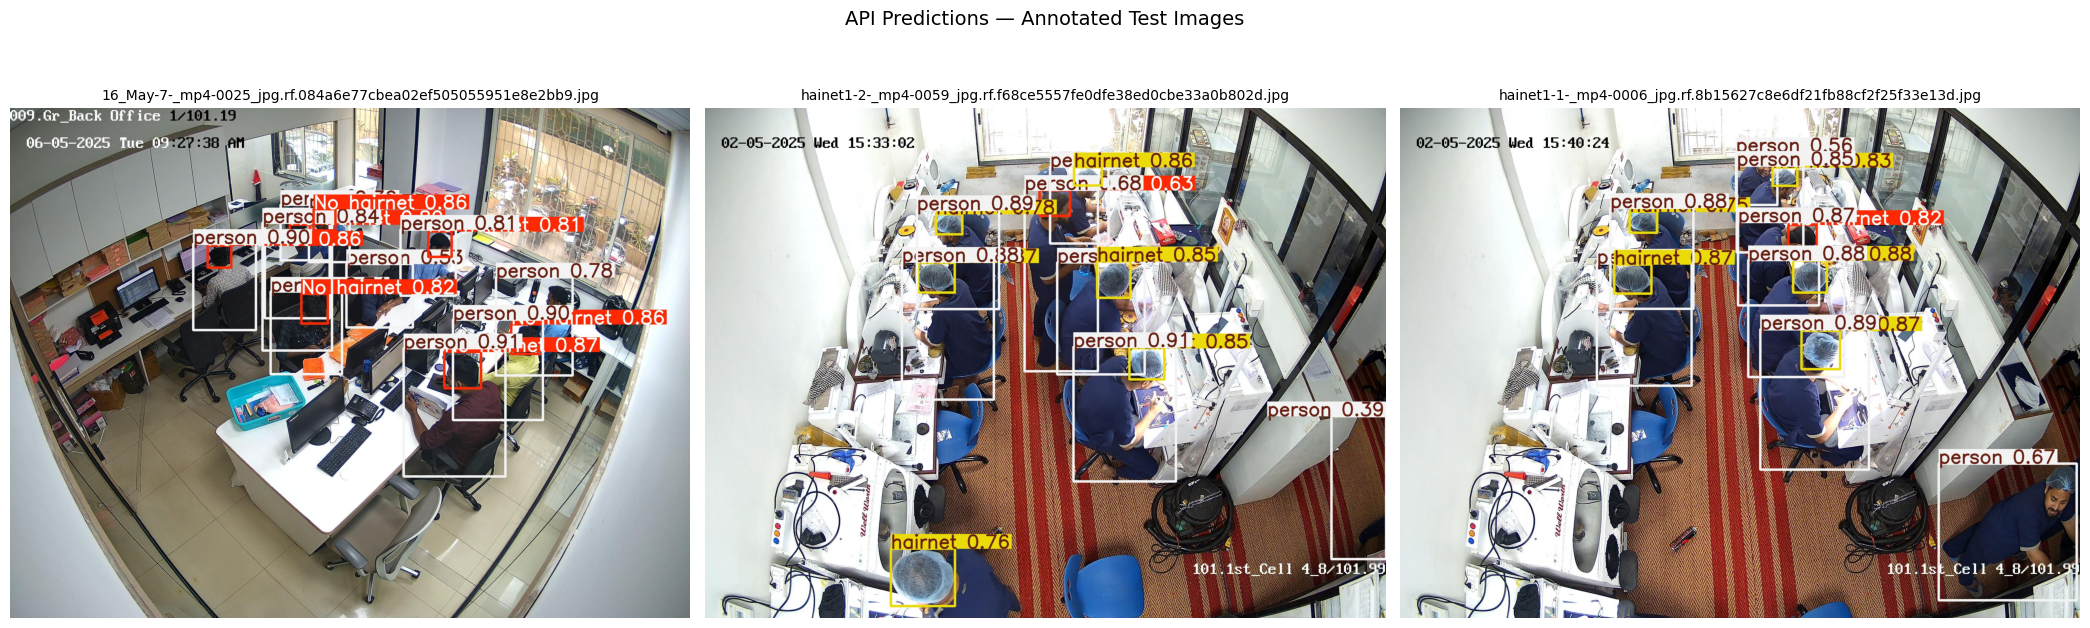


Saved → outputs/deployment_test.png


In [3]:
import base64
import random
from PIL import Image
import io
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Pick 3 random images from test set
TEST_DIR = Path('HairNet-Compliance-Detection-1/test/images')
test_images = list(TEST_DIR.glob('*.jpg')) + list(TEST_DIR.glob('*.png'))

if not test_images:
    print('No test images found — check TEST_DIR path')
else:
    samples = random.sample(test_images, min(3, len(test_images)))

    fig, axes = plt.subplots(1, len(samples), figsize=(7 * len(samples), 7))
    if len(samples) == 1:
        axes = [axes]

    for ax, img_path in zip(axes, samples):
        with open(img_path, 'rb') as f:
            resp = requests.post(
                f'{API_URL}/predict',
                files={'file': (img_path.name, f, 'image/jpeg')},
            )

        data = resp.json()

        print(f'\n── {img_path.name}')
        print(f'   inference_ms  : {data["inference_ms"]}')
        print(f'   num_detections: {data["num_detections"]}')
        for d in data['detections']:
            print(f'   {d["class"]:<15} conf={d["confidence"]}')

        # Decode annotated image from base64 and display
        img_bytes = base64.b64decode(data['annotated_image_base64'])
        img = Image.open(io.BytesIO(img_bytes))
        ax.imshow(img)
        ax.set_title(img_path.name, fontsize=10)
        ax.axis('off')

    plt.suptitle('API Predictions — Annotated Test Images', fontsize=14)
    plt.tight_layout()
    plt.savefig('outputs/deployment_test.png', dpi=150)
    plt.show()
    print('\nSaved → outputs/deployment_test.png')